(d) [5 points] [Coding Problem] Classical (Unsupervised) EM Implementation. For
this sub-question, we are only going to consider the m unlabelled examples. Follow the
instructions in src/p04 gmm.py to implement the traditional EM algorithm, and run it on
the unlabelled data-set until convergence.
Run three trials and use the provided plotting function to construct a scatter plot of the
resulting assignments to clusters (one plot for each trial). Your plot should indicate clus-
ter assignments with colors they got assigned to (i.e., the cluster which had the highest
probability in the final E-step).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PLOT_COLORS = ["red", "green", "blue", "orange"]  # Colors for your plots
K = 4  # Number of Gaussians in the mixture model
NUM_TRIALS = 3  # Number of trials to run (can be adjusted for debugging)
UNLABELED = -1  # Cluster label for unlabeled data points (do not change)


def main(is_semi_supervised, trial_num):
    """Problem 3: EM for Gaussian Mixture Models (unsupervised and semi-supervised)"""
    print(
        "Running {} EM algorithm...".format(
            "semi-supervised" if is_semi_supervised else "unsupervised"
        )
    )

    # Load dataset
    train_path = Path("data") / "ds3_train.csv"
    x, z = load_gmm_dataset(train_path)
    x_tilde = None

    if is_semi_supervised:
        # Split into labeled and unlabeled examples
        labeled_idxs = (z != UNLABELED).squeeze()
        x_tilde = x[labeled_idxs, :]  # Labeled examples
        z = z[labeled_idxs, :]  # Corresponding labels
        x = x[~labeled_idxs, :]  # Unlabeled examples

    # *** START CODE HERE ***
    # (1) Initialize mu and sigma by splitting the m data points uniformly at random
    # into K groups, then calculating the sample mean and covariance for each group
    # (2) Initialize phi to place equal probability on each Gaussian
    # phi should be a numpy array of shape (K,)
    # (3) Initialize the w values to place equal probability on each Gaussian
    # w should be a numpy array of shape (m, K)
    # *** END CODE HERE ***
    m, n = x.shape
    index = np.arange(m)
    np.random.shuffle(index)
    random_groups = []#np.zeros(K)
    for i in np.split(index, K):
        random_groups.append(x[i,:])

    mu = []
    sigma = []
    for i in random_groups:
        mu.append(np.mean(i, axis = 0))
        sigma.append(np.cov(i, rowvar=False))

    phi = np.ones(K) * 1/K

    w = np.ones((m, K))*1/K

    if is_semi_supervised:
        w, it = run_semi_supervised_em(x, x_tilde, z, w, phi, mu, sigma)
    else:
        w, it = run_em(x, w, phi, mu, sigma)
    print(f"Nº of iterations to converge: {it}")
    # Plot your predictions
    z_pred = np.zeros(m)
    if w is not None:  # Just a placeholder for the starter code
        for i in range(m):
            z_pred[i] = np.argmax(w[i])

    plot_gmm_preds(x, z_pred, is_semi_supervised, plot_id=trial_num)


def run_em(x, w, phi, mu, sigma):
    """Problem 3(d): EM Algorithm (unsupervised).

    See inline comments for instructions.

    Args:
        x: Design matrix of shape (m, n).
        w: Initial weight matrix of shape (m, k).
        phi: Initial mixture prior, of shape (k,).
        mu: Initial cluster means, list of k arrays of shape (n,).
        sigma: Initial cluster covariances, list of k arrays of shape (n, n).

    Returns:
        Updated weight matrix of shape (m, k) resulting from EM algorithm.
        More specifically, w[i, j] should contain the probability of
        example x^(i) belonging to the j-th Gaussian in the mixture.
    """
    # No need to change any of these parameters
    eps = 1e-3  # Convergence threshold
    max_iter = 1000

    # Stop when the absolute change in log-likelihood is < eps
    # See below for explanation of the convergence criterion
    it = 0
    ll = prev_ll = None
    m, n = x.shape
    _, k = w.shape
    while it < max_iter and (prev_ll is None or np.abs(ll - prev_ll) >= eps):
          # Just a placeholder for the starter code
        # *** START CODE HERE
        # (1) E-step: Update your estimates in w
        # (2) M-step: Update the model parameters phi, mu, and sigma
        # (3) Compute the log-likelihood of the data to check for convergence.
        # By log-likelihood, we mean `ll = sum_x[log(sum_z[p(x|z) * p(z)])]`.
        # We define convergence by the first iteration where abs(ll - prev_ll) < eps.
        # Hint: For debugging, recall part (a). We showed that ll should be monotonically increasing.
        # *** END CODE HERE ***
        inv_sigma = []
        det_sigma = []
        for j in range(k):
            inv_sigma.append(np.linalg.inv(sigma[j]))
            det_sigma.append(np.linalg.det(sigma[j]))
        for i in range(m):
            suma = 0
            for j in range(k):
                diff = x[i] - mu[j]
                coef = 1.0 / ((2 * np.pi)**(n/2) * det_sigma[j]**(1/2))
                expo = np.exp(-0.5 * diff.T @ inv_sigma[j] @ diff)
                gaussian_ij = coef * expo
                w[i, j] = phi[j] * gaussian_ij
                suma += w[i, j] 
            w[i, :] /= suma   
        #M-Step
        N = np.sum(w, axis = 0)
        phi = N/m
        mu = w.T@x/N[:, None]
        for j in range(k):
            diff = x - mu[j]           
            weighted = w[:, j][:, None] * diff
            sigma[j] = (weighted.T @ diff) / N[j]
            inv_sigma.append(np.linalg.inv(sigma[j]))
            det_sigma.append(np.linalg.det(sigma[j]))
            
        prev_ll = ll
        ll = 0.0
        for i in range(m):
            s = 0.0
            for j in range(k):
                diff = x[i] - mu[j]
                coef = 1.0 / ((2*np.pi)**(n/2) * np.sqrt(det_sigma[j]))
                expo = np.exp(-0.5 * diff.T @ inv_sigma[j] @ diff)
                s += phi[j] * coef * expo   # sum_z p(x|z)p(z)
            ll += np.log(s)

        it += 1
    return w, it



def run_semi_supervised_em(x, x_tilde, z, w, phi, mu, sigma):
    """Problem 3(e): Semi-Supervised EM Algorithm.

    See inline comments for instructions.

    Args:
        x: Design matrix of unlabeled examples of shape (m, n).
        x_tilde: Design matrix of labeled examples of shape (m_tilde, n).
        z: Array of labels of shape (m_tilde, 1).
        w: Initial weight matrix of shape (m, k).
        phi: Initial mixture prior, of shape (k,).
        mu: Initial cluster means, list of k arrays of shape (n,).
        sigma: Initial cluster covariances, list of k arrays of shape (n, n).

    Returns:
        Updated weight matrix of shape (m, k) resulting from semi-supervised EM algorithm.
        More specifically, w[i, j] should contain the probability of
        example x^(i) belonging to the j-th Gaussian in the mixture.
    """
    # No need to change any of these parameters
    alpha = 20.0  # Weight for the labeled examples
    eps = 1e-3  # Convergence threshold
    max_iter = 1000

    # Stop when the absolute change in log-likelihood is < eps
    # See below for explanation of the convergence criterion
    it = 0
    ll = prev_ll = None
    m, n = x.shape
    _, k = w.shape
    m_tilde, _ = x_tilde.shape

    inv_sigma = [np.linalg.inv(sigma[j]) for j in range(k)]
    det_sigma = [np.linalg.det(sigma[j]) for j in range(k)]

    while it < max_iter and (prev_ll is None or np.abs(ll - prev_ll) >= eps):
          # Just a placeholder for the starter code
        # *** START CODE HERE
        # (1) E-step: Update your estimates in w
        # (2) M-step: Update the model parameters phi, mu, and sigma
        # (3) Compute the log-likelihood of the data to check for convergence.
        # By log-likelihood, we mean `ll = sum_x[log(sum_z[p(x|z) * p(z)])]`.
        # We define convergence by the first iteration where abs(ll - prev_ll) < eps.
        # Hint: For debugging, recall part (a). We showed that ll should be monotonically increasing.
        # *** END CODE HERE ***
        for i in range(m):
            suma = 0
            for j in range(k):
                diff = x[i] - mu[j]
                coef = 1.0 / ((2 * np.pi)**(n/2) * det_sigma[j]**(1/2))
                expo = np.exp(-0.5 * diff.T @ inv_sigma[j] @ diff)
                gaussian_ij = coef * expo
                w[i, j] = phi[j] * gaussian_ij
                suma += w[i, j] 
            w[i, :] /= suma   
        #M-Step
        labels = z.ravel().astype(int)
        N = np.sum(w, axis = 0)
        N_supervised = np.bincount(labels, minlength=k)

        phi = (N + alpha * N_supervised)/(m + alpha*m_tilde)

        supervised_sums = np.zeros((k, n))
        for j in range(k):
            mask_j = (labels == j)
            if np.any(mask_j):
                supervised_sums[j] = np.sum(x_tilde[mask_j], axis=0)

        # Means
        mu = (w.T @ x + alpha * supervised_sums) / (
            N[:, None] + alpha * N_supervised[:, None]
        )

        # Covariances
        for j in range(k):
            # Unlabeled diffs
            diff = x - mu[j]               # (m, n)
            cov_unlabeled = (w[:, j][:, None] * diff).T @ diff  # (n, n)

            # Labeled diffs for class j
            mask_j = (labels == j)
            diff_tilde_j = x_tilde[mask_j] - mu[j]              # (#supervised_j, n)
            if diff_tilde_j.shape[0] > 0:
                cov_supervised = diff_tilde_j.T @ diff_tilde_j
            else:
                cov_supervised = 0.0

            # Combine
            sigma[j] = (cov_unlabeled + alpha * cov_supervised) / (
                N[j] + alpha * N_supervised[j]
            )

        # Update inverses & determinants for E-step / LL
        inv_sigma = [np.linalg.inv(sigma[j]) for j in range(k)]
        det_sigma = [np.linalg.det(sigma[j]) for j in range(k)]

        prev_ll = ll
        ll = 0.0
        # Unlabeled part
        for i in range(m):
            s = 0.0
            for j in range(k):
                diff = x[i] - mu[j]
                coef = 1.0 / ((2*np.pi)**(n/2) * np.sqrt(det_sigma[j]))
                expo = np.exp(-0.5 * diff.T @ inv_sigma[j] @ diff)
                s += phi[j] * coef * expo
            ll += np.log(s)

        # Labeled part
        for i in range(m_tilde):
            j = labels[i]
            diff_tilde = x_tilde[i] - mu[j]
            coef = 1.0 / ((2*np.pi)**(n/2) * np.sqrt(det_sigma[j]))
            expo_tilde = np.exp(-0.5 * diff_tilde.T @ inv_sigma[j] @ diff_tilde)
            p = phi[j] * coef * expo_tilde
            ll += alpha * np.log(p)   # weight labeled contribution
        it += 1
    return w, it


# *** START CODE HERE ***
# Helper functions
# *** END CODE HERE ***


def plot_gmm_preds(x, z, with_supervision, plot_id):
    """Plot GMM predictions on a 2D dataset `x` with labels `z`.

    Write to the output directory, including `plot_id`
    in the name, and appending 'ss' if the GMM had supervision.

    NOTE: You do not need to edit this function.
    """
    plt.figure(figsize=(12, 8))
    plt.title(
        "{} GMM Predictions".format(
            "Semi-supervised" if with_supervision else "Unsupervised"
        )
    )
    plt.xlabel("x_1")
    plt.ylabel("x_2")

    for x_1, x_2, z_ in zip(x[:, 0], x[:, 1], z):
        color = "gray" if z_ < 0 else PLOT_COLORS[int(z_)]
        alpha = 0.25 if z_ < 0 else 0.75
        plt.scatter(x_1, x_2, marker=".", c=color, alpha=alpha)

    #file_name = "p03_pred{}_{}.pdf".format("_ss" if with_supervision else "", plot_id)
    #save_path = os.path.join("output", file_name)
    #plt.savefig(save_path)


def load_gmm_dataset(csv_path):
    """Load dataset for Gaussian Mixture Model (problem 3).

    Args:
         csv_path: Path to CSV file containing dataset.

    Returns:
        x: NumPy array shape (m, n)
        z: NumPy array shape (m, 1)

    NOTE: You do not need to edit this function.
    """

    # Load headers
    with open(csv_path, "r") as csv_fh:
        headers = csv_fh.readline().strip().split(",")

    # Load features and labels
    x_cols = [i for i in range(len(headers)) if headers[i].startswith("x")]
    z_cols = [i for i in range(len(headers)) if headers[i] == "z"]

    x = np.loadtxt(csv_path, delimiter=",", skiprows=1, usecols=x_cols, dtype=float)
    z = np.loadtxt(csv_path, delimiter=",", skiprows=1, usecols=z_cols, dtype=float)

    if z.ndim == 1:
        z = np.expand_dims(z, axis=-1)

    return x, z


Running unsupervised EM algorithm...
Nº of iterations to converge: 117
Running unsupervised EM algorithm...
Nº of iterations to converge: 177
Running unsupervised EM algorithm...
Nº of iterations to converge: 113


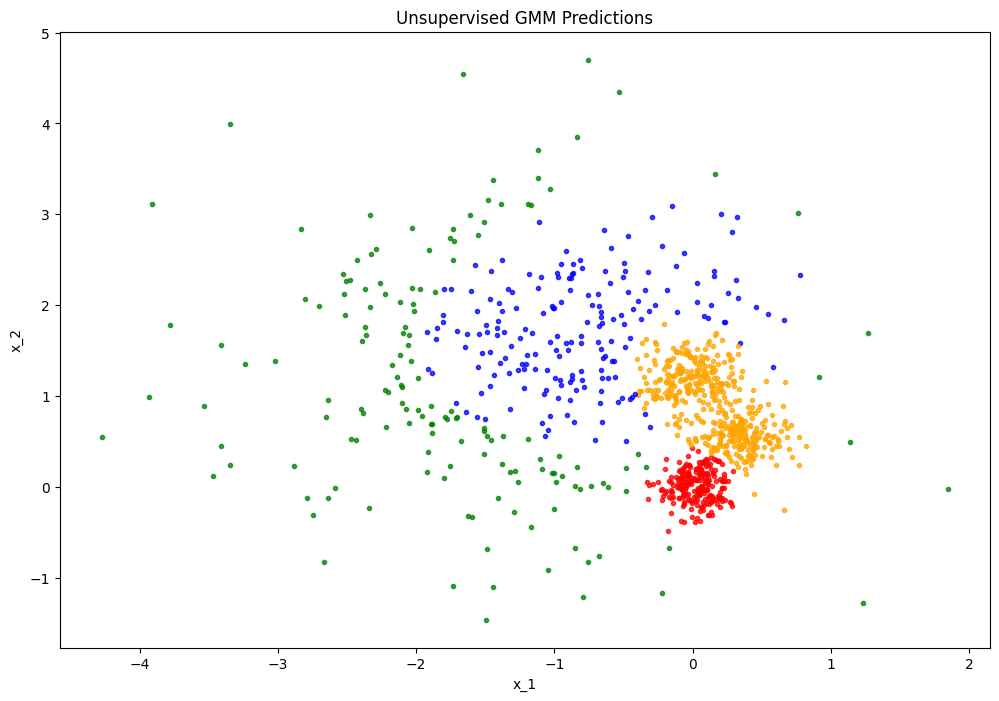

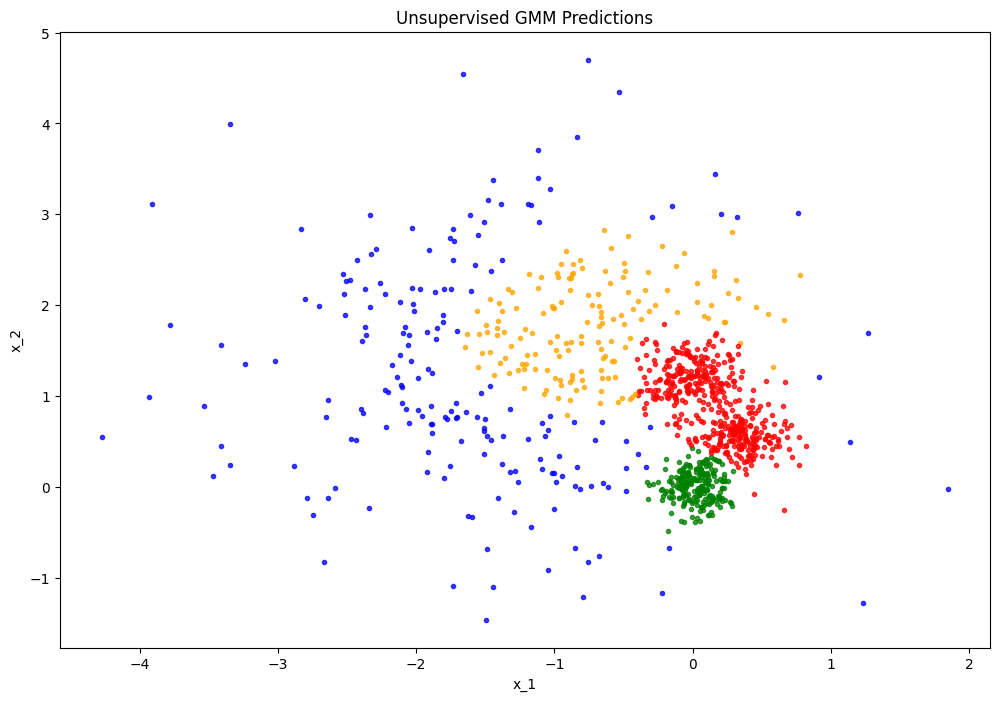

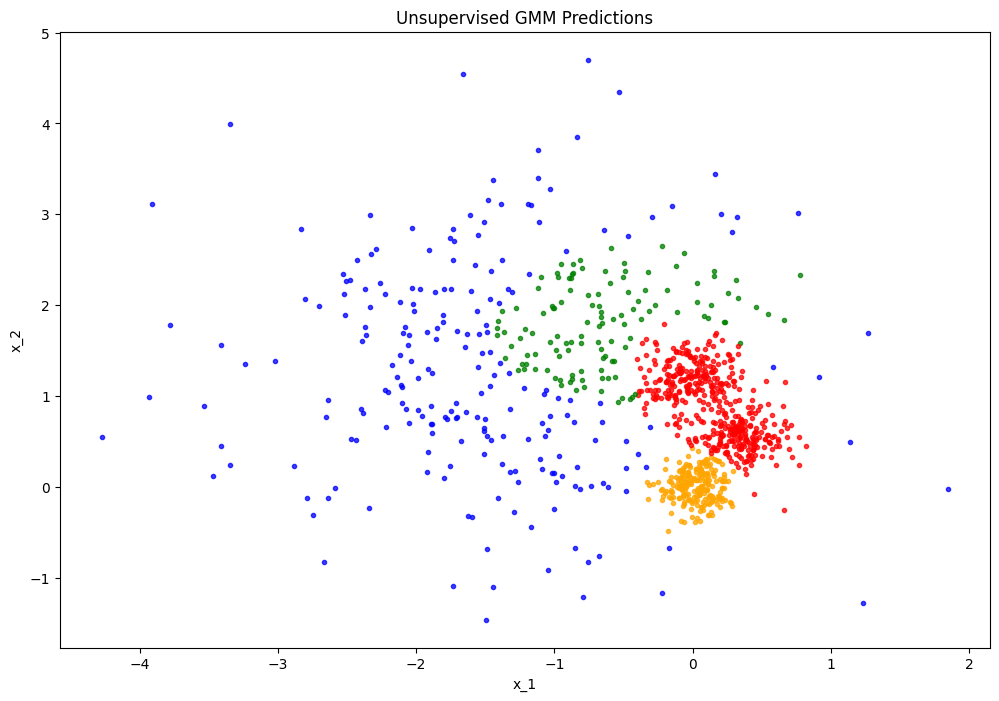

In [2]:
#Unsupervised case
np.random.seed(229)
# Run NUM_TRIALS trials to see how different initializations
# affect the final predictions with and without supervision
for t in range(NUM_TRIALS):
    main(is_semi_supervised=False, trial_num=t)

Running semi-supervised EM algorithm...
Nº of iterations to converge: 24
Running semi-supervised EM algorithm...
Nº of iterations to converge: 24
Running semi-supervised EM algorithm...
Nº of iterations to converge: 25


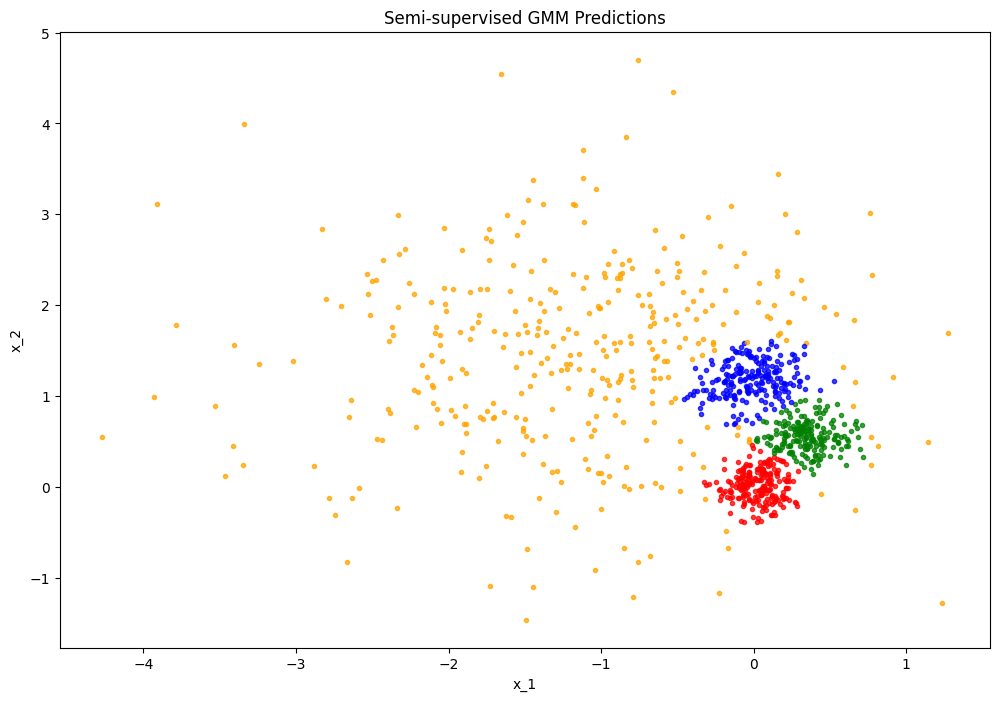

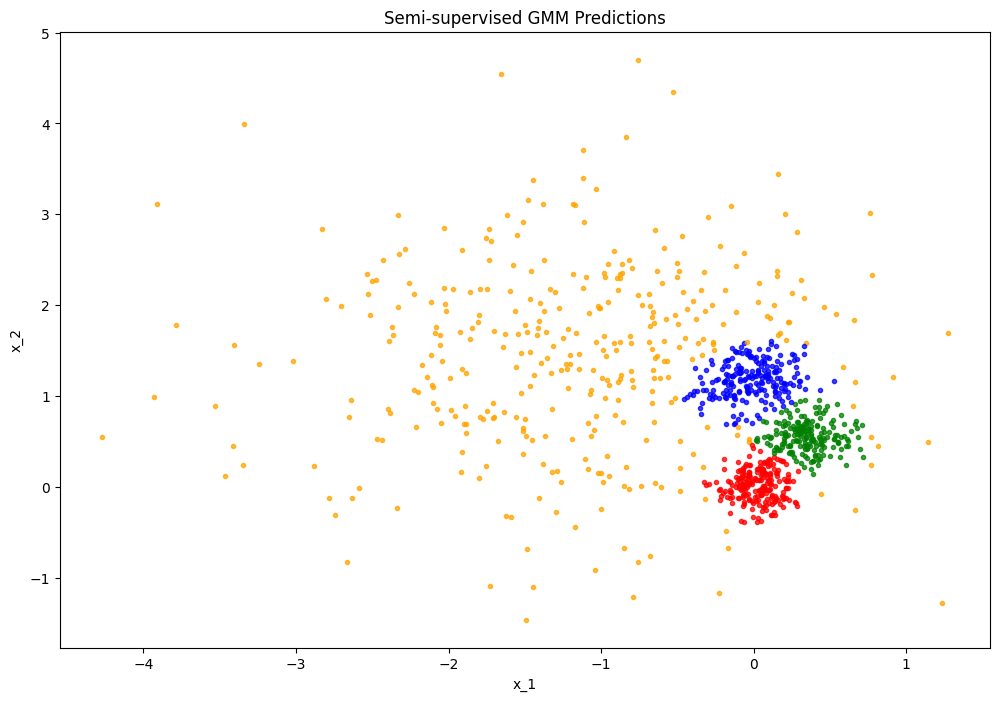

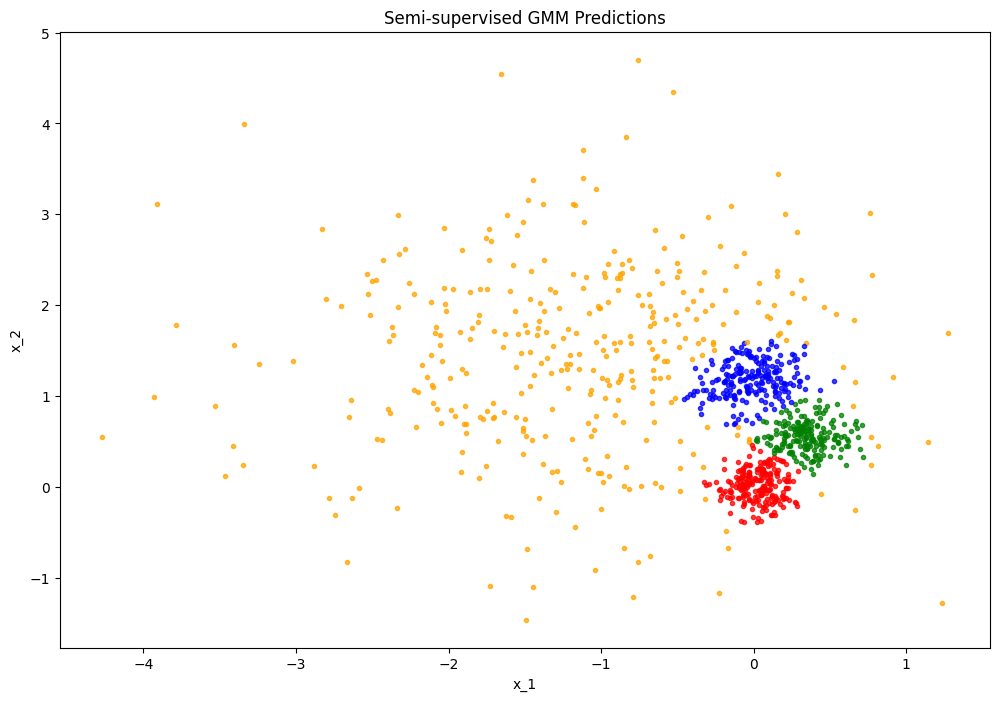

In [3]:
#semi-supervised case
for t in range(NUM_TRIALS):
    main(is_semi_supervised=True, trial_num=t)

(f)  Comparison of Unsupervised and Semi-supervised EM. Briefly describe
the differences you saw in unsupervised vs. semi-supervised EM for each of the following:

i. Number of iterations taken to converge.

ii. Stability (i.e., how much did assignments change with different random initializations?)

iii. Overall quality of assignments.

Note: The dataset was sampled from a mixture of three low-variance Gaussian distributions, and a fourth, high-variance Gaussian distribution. This should be useful in deter-
mining the overall quality of the assignments that were found by the two algorithms.


i. We can see that the number of iterations that the semi-supervised algorithm needs to converge is approximately 5 times smaller than the unsupervised case (24 vs 135 iterations). 

ii. The assigments made by the unsupervised algorithm are different for each inicializarion while the semi-supervised algorithm assigments are the same.

iii. We know that the dataset was sampled from a mixture of three low-variance gayssians and a fourth high-variance distribution. This is exactly what wee see in the semi-supervised case, in which the blue, green and red poitns belongs to a low-variance gaussian while the orange dots belongs to the high-variance gaussian. The unsupervised assigments seems to correspond to three high variance gaussians and one low-variance gaussian.